<a href="https://colab.research.google.com/github/ratwet/ShadowFox/blob/Preview/Task1_Image_Tagging/Image_Tagging_CNN_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using Convolutional Neural Networks
**Dataset:** CIFAR-10 — 60,000 color images (32x32) across 10 classes

**Classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Approach:** CNN designed from scratch using TensorFlow/Keras, trained for 25 epochs with data augmentation and dropout regularization.
> Run on Google Colab with T4 GPU enabled: Runtime > Change runtime type > GPU


## Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:" , gpus[0].name if gpus else "None (CPU only)")


TensorFlow: 2.20.0
GPU: /physical_device:GPU:0


## Load CIFAR-10

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 118s 1us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


### Sample images

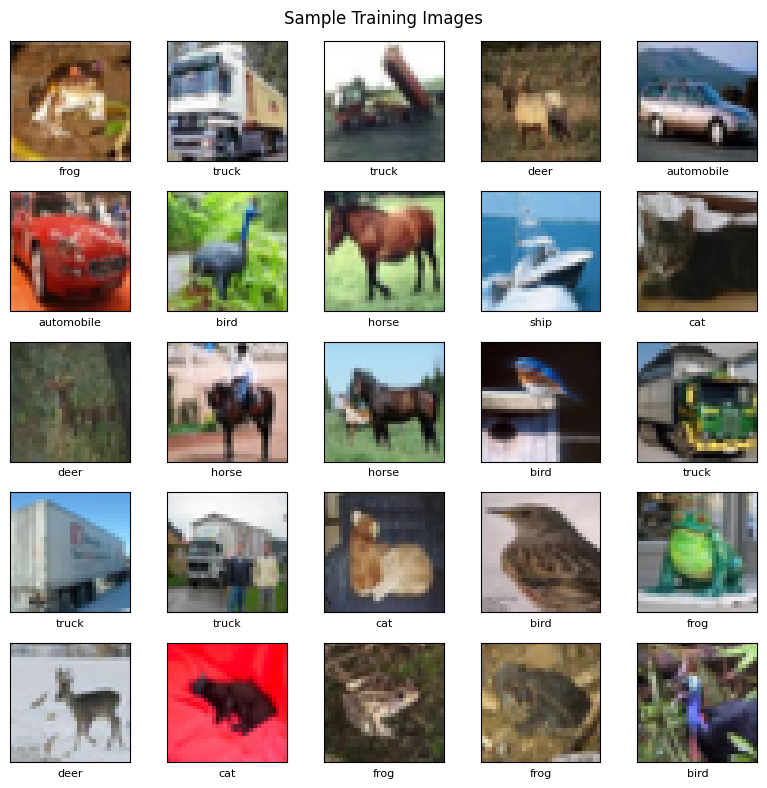

In [3]:
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_xlabel(class_names[y_train[i]], fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=100, bbox_inches='tight')
plt.show()


## Preprocessing

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
print("Pixel range:", x_train.min(), "-", x_train.max())


Pixel range: 0.0 - 1.0


## Data Augmentation

In [5]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")


## Model Architecture

In [6]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name="cifar10_cnn")

model.summary()


Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

## Compile

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Training (25 epochs)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.2550 - loss: 2.0017 - val_accuracy: 0.4326 - val_loss: 1.5356 - learning_rate: 0.0010
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3631 - loss: 1.7145 - val_accuracy: 0.4448 - val_loss: 1.5030 - learning_rate: 0.0010
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4223 - loss: 1.5767 - val_accuracy: 0.5104 - val_loss: 1.3826 - learning_rate: 0.0010
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4652 - loss: 1.4748 - val_accuracy: 0.5064 - val_loss: 1.4629 - learning_rate: 0.0010
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5064 - loss: 1.3792 - val_accuracy: 0.4784 - val_loss: 1.6642 - learning_rate: 0.0010
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5335 - loss: 1.3114 - val_accuracy: 0.6356 - val_loss: 1.1265 - learning_rate: 0.0010
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5541 - l

## Training Curves

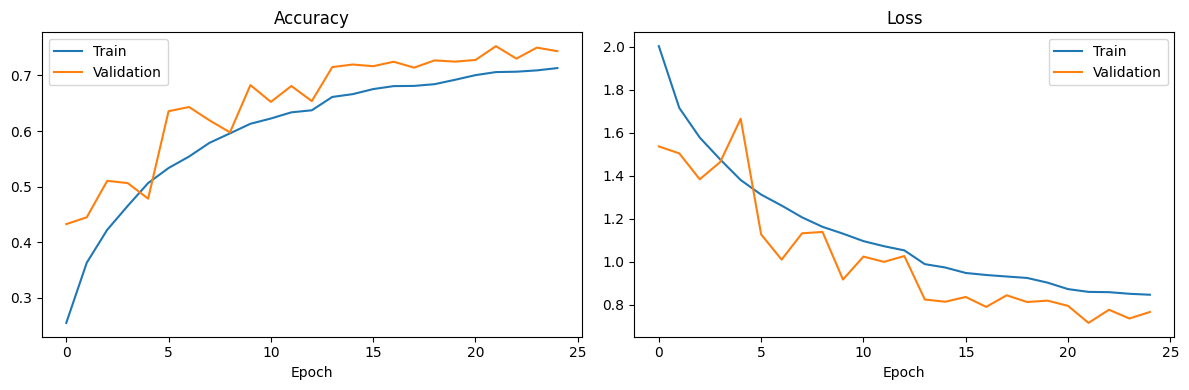

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100, bbox_inches='tight')
plt.show()


## Evaluation on Test Set

In [10]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")


Test Accuracy : 74.07%
Test Loss     : 0.7495


## Precision, Recall, F1 & Confusion Matrix

              precision    recall  f1-score   support

    airplane       0.75      0.79      0.77      1000
  automobile       0.87      0.92      0.89      1000
        bird       0.73      0.54      0.62      1000
         cat       0.65      0.44      0.53      1000
        deer       0.68      0.70      0.69      1000
         dog       0.80      0.52      0.63      1000
        frog       0.58      0.90      0.71      1000
       horse       0.76      0.83      0.80      1000
        ship       0.85      0.89      0.87      1000
       truck       0.79      0.88      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.73     10000
weighted avg       0.75      0.74      0.73     10000



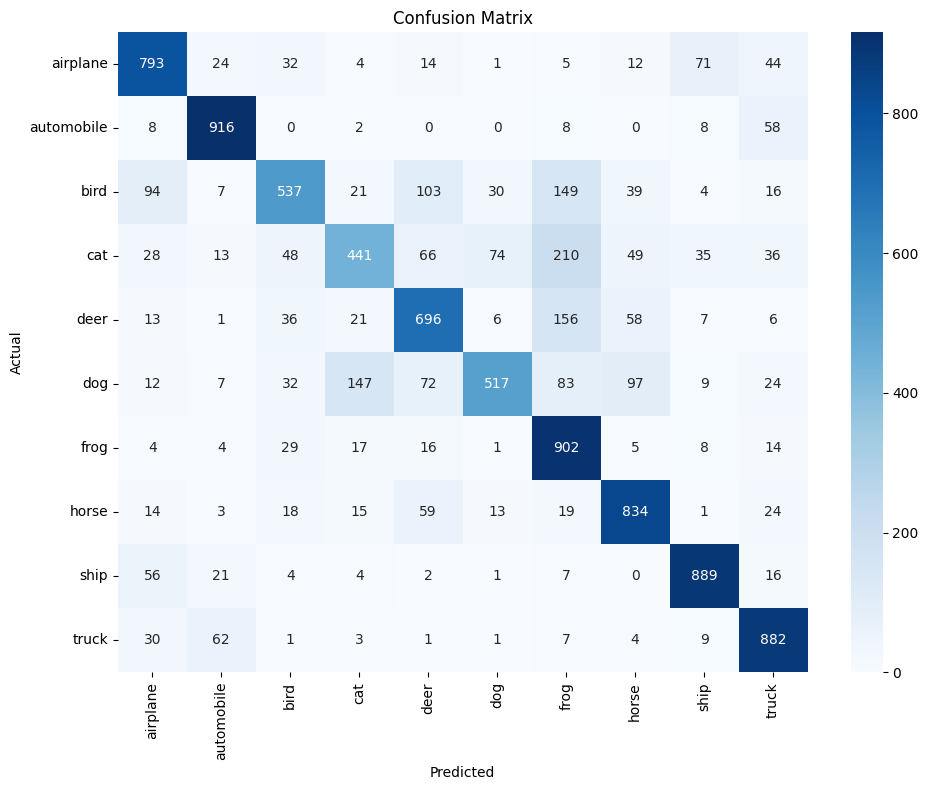

In [11]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches='tight')
plt.show()


## Sample Predictions

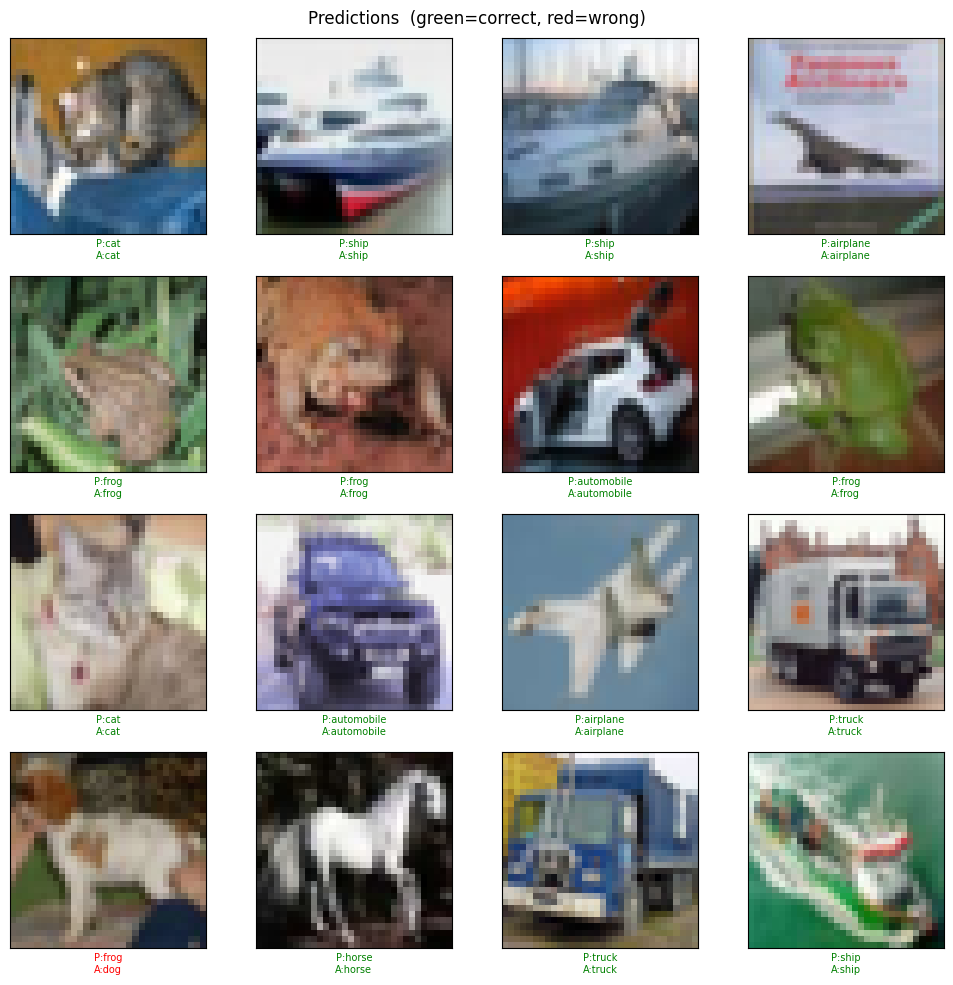

In [12]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[i])
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.xlabel(f"P:{class_names[y_pred[i]]}\nA:{class_names[y_test[i]]}", color=color, fontsize=7)
    plt.xticks([]); plt.yticks([])
plt.suptitle("Predictions  (green=correct, red=wrong)")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=100, bbox_inches='tight')
plt.show()


## Save Model

In [13]:
model.save('cifar10_cnn.h5')
print("Model saved.")


Model saved.
